<a href="https://colab.research.google.com/github/monem8795/Data-Analytics/blob/main/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Linear Regression Analysis

In [ ]:
### load the data from BTS
URL = "https://data.bts.gov/resource/y5ut-ibwt.json?$query=SELECT%0A%20%20%60id%60%2C%0A%20%20%60date%60%2C%0A%20%20%60year%60%2C%0A%20%20%60indicator%60%2C%0A%20%20%60measure1%60%2C%0A%20%20%60measure2%60%2C%0A%20%20%60measure1_description%60%2C%0A%20%20%60measure2_description%60%2C%0A%20%20%60value1%60%2C%0A%20%20%60units%60%2C%0A%20%20%60note%60%2C%0A%20%20%60source%60"

In [ ]:
query = """
SELECT
  `id`,
  `date`,
  `year`,
  `indicator`,
  `measure1`,
  `measure2`,
  `measure1_description`,
  `measure2_description`,
  `value1`,
  `units`,
  `note`,
  `source`
  LIMIT 50000
  """

In [ ]:
from urllib.parse import quote

URL = "https://data.bts.gov/resource/y5ut-ibwt.json?$query={quote(query)}"

In [ ]:
import pandas as pd
URL = URL = f"https://data.bts.gov/resource/y5ut-ibwt.json?$query={quote(query)}"
df = pd.read_json(URL)


In [ ]:
df

,id,date,year,indicator,value1,units,note,source,measure1,measure1_description,measure2,measure2_description
0,1_2019_01_06,2019-01-06,2019,Capacity of Containerships Calling at U.S. Por...,1692044.0,TEUs,This series is now based on CBP's Vessel Manag...,MARAD Office of Policy and Plans analysis of C...,NaN,NaN,NaN,NaN
1,1_2019_01_13,2019-01-13,2019,Capacity of Containerships Calling at U.S. Por...,2032538.0,TEUs,This series is now based on CBP's Vessel Manag...,MARAD Office of Policy and Plans analysis of C...,NaN,NaN,NaN,NaN
2,1_2019_01_20,2019-01-20,2019,Capacity of Containerships Calling at U.S. Por...,2037507.0,TEUs,This series is now based on CBP's Vessel Manag...,MARAD Office of Policy and Plans analysis of C...,NaN,NaN,NaN,NaN
3,1_2019_01_27,2019-01-27,2019,Capacity of Containerships Calling at U.S. Por...,2032424.0,TEUs,This series is now based on CBP's Vessel Manag...,MARAD Office of Policy and Plans analysis of C...,NaN,NaN,NaN,NaN
4,1_2019_02_03,2019-02-03,2019,Capacity of Containerships Calling at U.S. Por...,2055851.0,TEUs,This series is now based on CBP's Vessel Manag...,MARAD Office of Policy and Plans analysis of C...,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
24854,"59_2026_03_14_Fort Worth, TX_BNSF",2026-03-14,2026,Average Dwell Time at Class I Railroad Terminals,30.5,Hours,NaN,Surface Transportation Board (STB),"Fort Worth, TX",Terminal,BNSF,Railroad name
24855,"59_2026_03_14_Memphis, TN_BNSF",2026-03-14,2026,Average Dwell Time at Class I Railroad Terminals,19.6,Hours,NaN,Surface Transportation Board (STB),"Memphis, TN",Terminal,BNSF,Railroad name
24856,"59_2026_03_21_Barstow, CA_BNSF",2026-03-21,2026,Average Dwell Time at Class I Railroad Terminals,24.8,Hours,NaN,Surface Transportation Board (STB),"Barstow, CA",Terminal,BNSF,Railroad name
24857,"59_2026_03_21_Fort Worth, TX_BNSF",2026-03-21,2026,Average Dwell Time at Class I Railroad Terminals,29.3,Hours,NaN,Surface Transportation Board (STB),"Fort Worth, TX",Terminal,BNSF,Railroad name


Cleaning The Data


In [ ]:
#### let's see what indicators are in the data
df["indicator"].unique()

array(['Capacity of Containerships Calling at U.S. Ports (in TEUs)',
       'Empty Export Containers (in TEUs), Aggregated Select U.S. Ports',
       'Containerized Exports at U.S. Ports in TEUs',
       'Containerized Imports at U.S. Ports in TEUs',
       'U.S. Class I Total Rail Non-Intermodal Carloads',
       'U.S. Class I Rail Intermodal Units',
       'U.S. Class I Containers on Rail Flat Cars',
       'U.S. Class I Trailers on a Rail Flat Car',
       'Freight Transportation Services Index',
       'Average Truck Speed in MPH at 10 Bottleneck Locations',
       'Average Planning Time Index at 10 Bottleneck Locations',
       'Average Truck Speed in MPH Around Port of Los Angeles-Long Beach',
       'Average Truck Speed in MPH Around Port of New York-New Jersey',
       'PTI Around Port of Los Angeles-Long Beach',
       'PTI Around Port of New York-New Jersey',
       'Number of Non-Farm Truck Transportation Employees \xa0in Thousands (Seasonally Adjusted)',
       'Number of W

In [ ]:
### we want to look at imports and exports at specific ports
import_df = df[df["indicator"]=="Loaded Import Containers at Select U.S. Ports in TEUs"]
export_df = df[df["indicator"]=="Loaded Export Containers at Select U.S. Ports in TEUs"]

In [ ]:
### rename generice colums
import_df = import_df.rename(columns={"measure1": "port"})
export_df = export_df.rename(columns={"measure1": "port"})

In [ ]:
# Let's rename the generic measure1 column to port
import_df = import_df.rename(columns={"measure1": "port", "value1": "import_teus"})
export_df = export_df.rename(columns={"measure1": "port", "value1": "export_teus"})

In [ ]:
# Let's only keep the columns we are interested in
import_df = import_df[["date", "import_teus", "port"]]
export_df = export_df[["date", "export_teus", "port"]]

In [ ]:
# Let's set an index
import_df = import_df.set_index(["date", "port"])
export_df = export_df.set_index(["date", "port"])

In [ ]:
# Since we've used two columns as the index, we now have a MultiIndex
# We can refer to a row by using the following syntax:
import_df.loc[("2019-01-01", "Houston")]

,2019-01-01
,Houston
import_teus,95318.0


In [ ]:
## let's join two dataframes together to have iport/export in one row
ie_df = import_df.join(export_df)
ie_df.reset_index(level = 1)


,port,import_teus,export_teus
date,,,
2019-01-01,Charleston,88107.00,63750.0
2019-01-01,Houston,95318.00,87961.0
2019-01-01,Long Beach,323838.00,131436.0
2019-01-01,Los Angeles,429922.75,144993.0
2019-01-01,NY-NJ,327345.00,111833.0
...,...,...,...
2025-12-01,NY-NJ,329914.00,105438.0
2025-12-01,Oakland,74031.00,66019.0
2025-12-01,Port of VA,127602.00,85160.0


## plotting the data


In [ ]:
import seaborn as sns


ConversionError: Failed to convert value(s) to axis units: date        port       
2019-01-01  Charleston      (2019-01-01 00:00:00, Charleston)
            Houston            (2019-01-01 00:00:00, Houston)
            Long Beach      (2019-01-01 00:00:00, Long Beach)
            Los Angeles    (2019-01-01 00:00:00, Los Angeles)
            NY-NJ                (2019-01-01 00:00:00, NY-NJ)
                                          ...                
2025-12-01  NY-NJ                (2025-12-01 00:00:00, NY-NJ)
            Oakland            (2025-12-01 00:00:00, Oakland)
            Port of VA      (2025-12-01 00:00:00, Port of VA)
            Savannah          (2025-12-01 00:00:00, Savannah)
            Sea-Tac            (2025-12-01 00:00:00, Sea-Tac)
Name: x, Length: 756, dtype: object

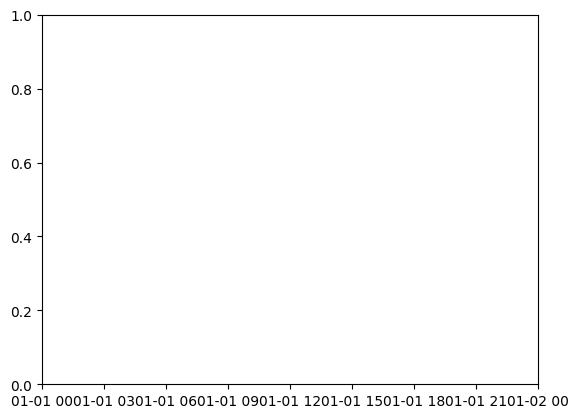

In [ ]:
sns.lineplot(ie_df, x=ie_df.index, y="import_teus", hue="port")

<Axes: xlabel='import_teus', ylabel='export_teus'>

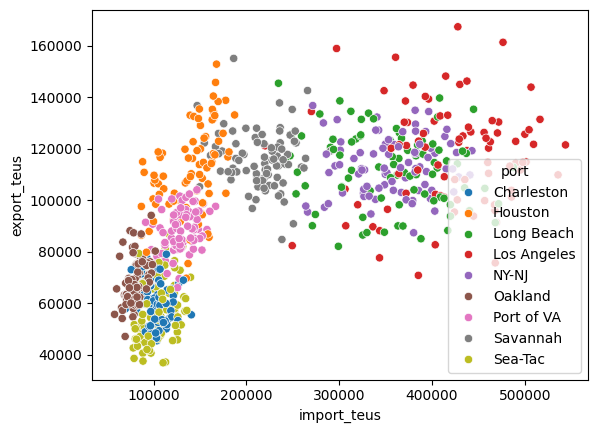

In [ ]:
sns.scatterplot(ie_df, x="import_teus", y="export_teus", hue="port")

Regression

In [ ]:
# Let's download statsmodels
!pip install statsmodels

In [ ]:
import statsmodels.api as sm

y = ie_df['export_teus']
X = sm.add_constant(ie_df['import_teus'])
model = sm.OLS(y,X).fit()


In [ ]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            export_teus   R-squared:                       0.444
Model:                            OLS   Adj. R-squared:                  0.443
Method:                 Least Squares   F-statistic:                     602.0
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           3.50e-98
Time:                        00:40:18   Log-Likelihood:                -8573.7
No. Observations:                 756   AIC:                         1.715e+04
Df Residuals:                     754   BIC:                         1.716e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        6.379e+04   1424.350     44.787      0.000     6.1e+04    6.66e+04
import_teus     0.1411      0.006     24.536      0.000       0.130       0.152
==============================================================================
Omnibus:                       18.187   Durbin-Watson:                   2.084
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               18.676
Skew:                           0.366   Prob(JB):                     8.80e-05
Kurtosis:                       2.760   Cond. No.                     4.75e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.75e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
model.pvalues

,0
const,1.219555e-214
import_teus,3.495077e-98


<Axes: xlabel='import_teus', ylabel='export_teus'>

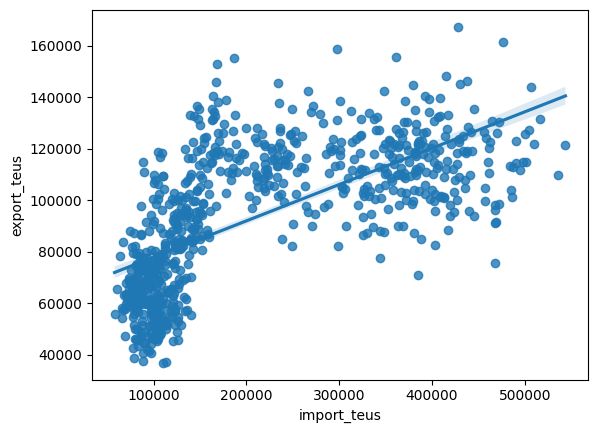

In [ ]:
sns.regplot(ie_df, x=ie_df["import_teus"], y=ie_df["export_teus"])

In [ ]:
# prediction line to make prediction
import numpy as np
model.predict(np.array([300_000]))

LEt's analyse the elationhip between the different ports

In [ ]:
ie2_df = ie_df.reset_index(level = 1)
ie2_df

,port,import_teus,export_teus
date,,,
2019-01-01,Charleston,88107.00,63750.0
2019-01-01,Houston,95318.00,87961.0
2019-01-01,Long Beach,323838.00,131436.0
2019-01-01,Los Angeles,429922.75,144993.0
2019-01-01,NY-NJ,327345.00,111833.0
...,...,...,...
2025-12-01,NY-NJ,329914.00,105438.0
2025-12-01,Oakland,74031.00,66019.0
2025-12-01,Port of VA,127602.00,85160.0


In [ ]:
ie2_df["port"].unique()

array(['Charleston', 'Houston', 'Long Beach', 'Los Angeles', 'NY-NJ',
       'Oakland', 'Port of VA', 'Savannah', 'Sea-Tac'], dtype=object)

In [ ]:
ports = ie2_df["port"].unique()

In [ ]:
y = ie2_df[ie2_df["port"] == "Savannah"]['import_teus']
X = sm.add_constant(ie2_df[ie2_df["port"] == "Los Angeles"]['import_teus'])
model = sm.OLS(y, X).fit()

In [ ]:
rsquares = []
for port in ports:
  port_rsquares = []
for port_2 in ports:
    y = ie2_df[ie2_df["port"] == port]['import_teus']
X = sm.add_constant(ie2_df[ie2_df["port"] == port_2]['import_teus'])
model = sm.OLS(y, X).fit()

port_rsquares.append(model.rsquared)
rsquares.append(port_rsquares)

In [ ]:
r_df = pd.DataFrame(rsquares, index=ports, columns=ports)

ValueError: 9 columns passed, passed data had 1 columns

In [ ]:
r_df = pd.DataFrame(rsquares, index=ports, columns=["R-Squared"])
r_df

,R-Squared
Charleston,1.0
Houston,1.0
Long Beach,1.0
Los Angeles,1.0
NY-NJ,1.0
Oakland,1.0
Port of VA,1.0
Savannah,1.0
Sea-Tac,1.0
